## Import Data

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
df = pd.read_csv("data/Fashion_Retail_Sales.csv")
print(df.head())
df.info()
df.describe()

   Customer Reference ID Item Purchased  Purchase Amount (USD) Date Purchase  \
0                   4018        Handbag                 4619.0    05-02-2023   
1                   4115          Tunic                 2456.0    11-07-2023   
2                   4019       Tank Top                 2102.0    23-03-2023   
3                   4097       Leggings                 3126.0    15-03-2023   
4                   3997         Wallet                 3003.0    27-11-2022   

   Review Rating Payment Method  
0            NaN    Credit Card  
1            2.0    Credit Card  
2            4.1           Cash  
3            3.2           Cash  
4            4.7           Cash  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3400 entries, 0 to 3399
Data columns (total 6 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Customer Reference ID  3400 non-null   int64  
 1   Item Purchased         3400 non-null   object 
 

,Customer Reference ID,Purchase Amount (USD),Review Rating
count,3400.000000,2750.000000,3076.000000
mean,4039.660588,156.709818,2.999057
std,48.122583,419.536669,1.156505
min,3957.000000,10.000000,1.000000
25%,3997.000000,57.000000,2.000000
50%,4040.000000,110.000000,3.000000
75%,4081.000000,155.750000,4.000000
max,4122.000000,4932.000000,5.000000


## Checking Missing Values

In [4]:
print(df.isna().sum())

Customer Reference ID      0
Item Purchased             0
Purchase Amount (USD)    650
Date Purchase              0
Review Rating            324
Payment Method             0
dtype: int64


## EDA

In [5]:
# General information before imputation missing value
df["Purchase Amount (USD)"].describe()
df["Review Rating"].describe()

count    3076.000000
mean        2.999057
std         1.156505
min         1.000000
25%         2.000000
50%         3.000000
75%         4.000000
max         5.000000
Name: Review Rating, dtype: float64

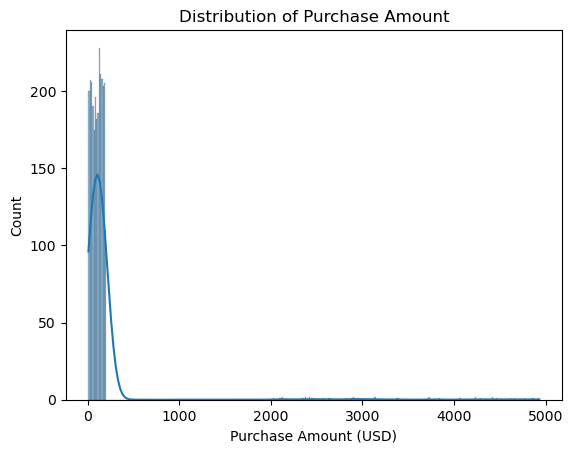

In [6]:
plt.figure()
sns.histplot(df["Purchase Amount (USD)"], kde=True)
plt.title("Distribution of Purchase Amount") #mirip chi suare gs sih ini gusy??
plt.show()

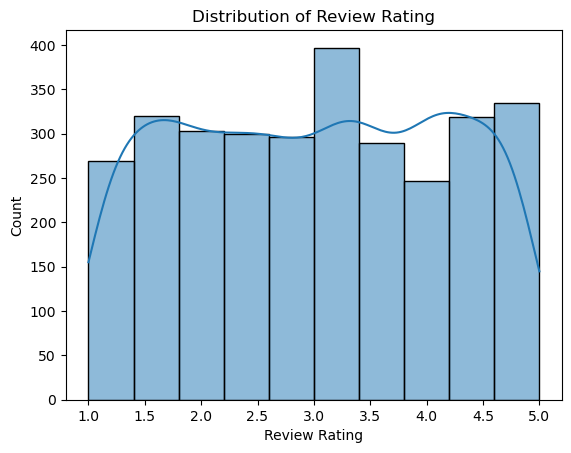

In [7]:
plt.figure()
sns.histplot(df["Review Rating"], bins=10, kde=True)
plt.title("Distribution of Review Rating")
plt.show()

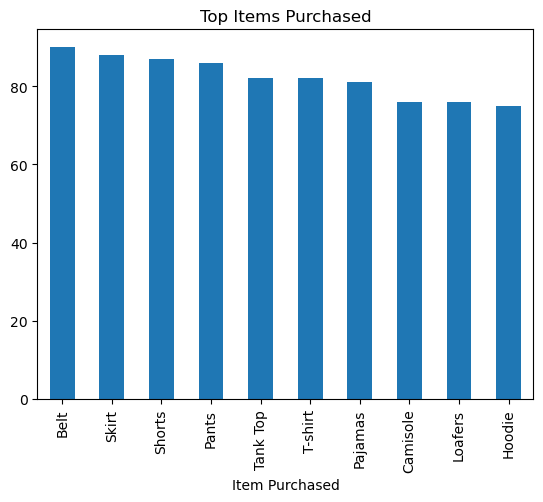

In [8]:
plt.figure()
df["Item Purchased"].value_counts().head(10).plot(kind="bar") ##bisa dimasukin ke dashboard jg ini
plt.title("Top Items Purchased")
plt.show()

In [9]:
df.groupby("Item Purchased")["Purchase Amount (USD)"].mean().sort_values(ascending=False).head(10)

Item Purchased
Tunic         319.907407
Flip-Flops    275.829268
Jeans         272.250000
Slippers      245.304348
Gloves        237.115385
Boots         228.673077
Handbag       214.711864
Sweater       213.137255
Pajamas       209.803279
Bowtie        197.840909
Name: Purchase Amount (USD), dtype: float64

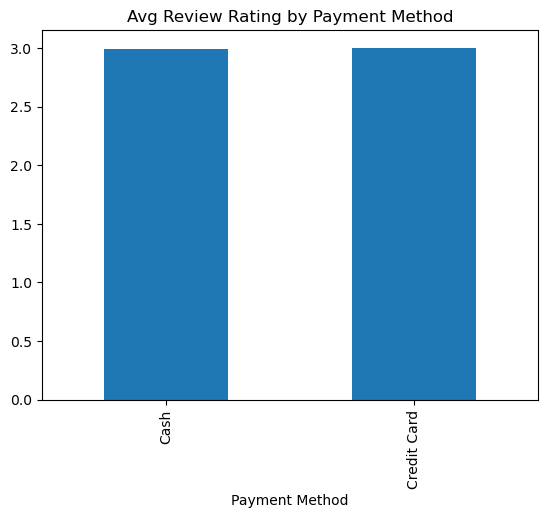

In [10]:
plt.figure()
df.groupby("Payment Method")["Review Rating"].mean().plot(kind="bar")
plt.title("Avg Review Rating by Payment Method")
plt.show()

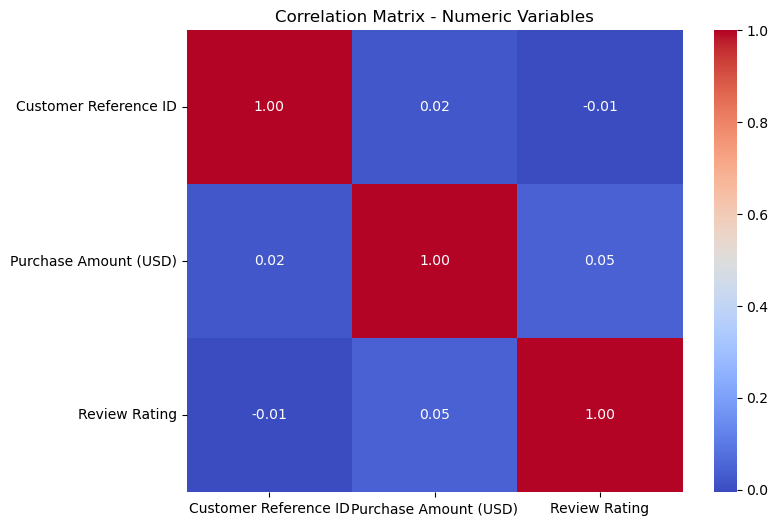

In [11]:
corr = df.select_dtypes(include=np.number).corr()
import matplotlib.pyplot as plt
import seaborn as sns

#visualization of heatmap corr
plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix - Numeric Variables")
plt.show()

## Imputation Missing Value

In [12]:
# Purchase Amount Imputation using mean each items
df["Purchase Amount (USD)"] = df["Purchase Amount (USD)"].fillna(
    df.groupby("Item Purchased")["Purchase Amount (USD)"].transform("mean")
)

# Review Rating imputation using median data
df["Review Rating"] = df["Review Rating"].fillna(
    df["Review Rating"].median()
)

# cek hasil
print(df.head())

   Customer Reference ID Item Purchased  Purchase Amount (USD) Date Purchase  \
0                   4018        Handbag                 4619.0    05-02-2023   
1                   4115          Tunic                 2456.0    11-07-2023   
2                   4019       Tank Top                 2102.0    23-03-2023   
3                   4097       Leggings                 3126.0    15-03-2023   
4                   3997         Wallet                 3003.0    27-11-2022   

   Review Rating Payment Method  
0            3.0    Credit Card  
1            2.0    Credit Card  
2            4.1           Cash  
3            3.2           Cash  
4            4.7           Cash  


In [13]:
print(df.isna().sum()) #kalau mau cek edanya lagi tinggal dirun ulang bagian eda untuk beforenya
# yang paling keliatan itu dibagian korelasi untuk before dan afternya

Customer Reference ID    0
Item Purchased           0
Purchase Amount (USD)    0
Date Purchase            0
Review Rating            0
Payment Method           0
dtype: int64


In [14]:
df.describe()

,Customer Reference ID,Purchase Amount (USD),Review Rating
count,3400.000000,3400.000000,3400.000000
mean,4039.660588,156.578638,2.999147
std,48.122583,377.892012,1.100005
min,3957.000000,10.000000,1.000000
25%,3997.000000,70.000000,2.100000
50%,4040.000000,118.531915,3.000000
75%,4081.000000,161.885593,3.900000
max,4122.000000,4932.000000,5.000000


In [16]:
df.to_csv("Fashion_Retail_Sales.csv", index=False)

STOP